## Fatalities

_Bang_. A gun fires on the streets of Philadelphia. The victim freezes in their tracks as they realize they've been shot, left to bleed out. What now? Is this a death sentence? Do they have any **shot** at survival? 

Gunshot wounds certainly have the potential to be fatal, but not all wounds are equal. Factors like the area of impact and the age of the victim can determine the fatal nature of a gunshot wound. Using gun violence data from [OpenDataPhilly](https://www.opendataphilly.org/dataset/shooting-victims), we can build an understanding of how different factors surrounding the circumstances of a shooting impact survival and fatality rates in Philadelphia.

## Wound Location

The location of the gunshot wound is the factor that impacts survival and fatality rates the most. According to a study conducted by the George Washington University School of Medicine and Health Sciences examining gun violence in Washington D.C., gun-related injuries to the brain, heart, and lungs have proven to be the most fatal. Do gun-related injuries in Philly follow a similar pattern? Let's find out:

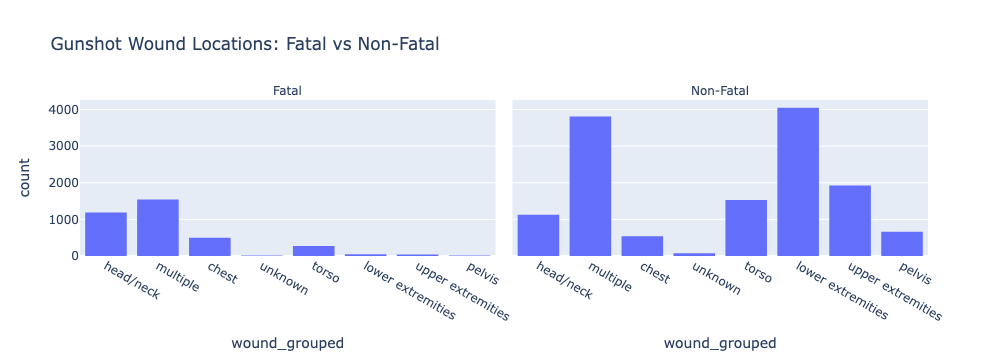

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import plotly.express as px
import warnings
warnings.simplefilter('ignore')

shoot_df = pd.read_csv('../../10b_DOW5/data/shootings.csv') 

shoot_df['wound_clean'] = (
    shoot_df['wound']
    .str.lower()
    .str.strip()
    .str.replace(r'multiple/?head', 'head', regex=True)
    .replace({'multi': 'multiple', 'knnes': 'knees'})
)

def group_wound(x):
    if pd.isna(x):
        return 'unknown'
    elif x in ['head', 'neck']:
        return 'head/neck'
    elif x in ['back', 'abdomen', 'stomach', 'torso']:
        return 'torso'
    elif x in ['groin', 'hips', 'pelvis', 'hip', 'buttocks']:
        return 'pelvis'
    elif x in ['arm', 'hand', 'wrist', 'shoulder']:
        return 'upper extremities'
    elif x in ['leg', 'thigh', 'knee', 'knees', 'ankle', 'foot', 'legs']:
        return 'lower extremities'
    elif x == 'multiple':
        return 'multiple'
    else:
        return x

shoot_df2 = shoot_df.copy()
shoot_df2['wound_grouped'] = shoot_df2['wound_clean'].apply(group_wound)
wound_counts = shoot_df2['wound_grouped'].value_counts()

fatal_notna = shoot_df2[shoot_df2['fatal'].notna()]

fatal_plot = px.histogram(
    fatal_notna,
    x='wound_grouped',
    facet_col='fatal',
    title='Gunshot Wound Locations: Fatal vs Non-Fatal'
)

fatal_plot.layout.annotations[0].text = 'Fatal'
fatal_plot.layout.annotations[1].text = 'Non-Fatal'

fatal_plot.show()

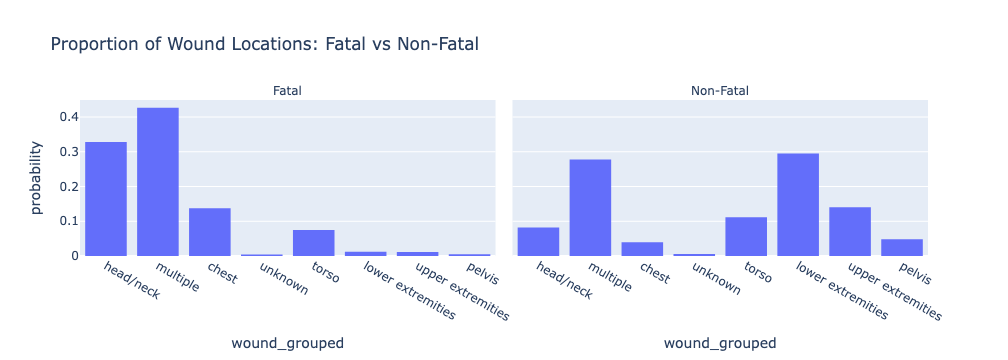

In [7]:
fatal_plot2 = px.histogram(
    fatal_notna,
    x='wound_grouped',
    facet_col='fatal',
    histnorm='probability',
    title='Proportion of Wound Locations: Fatal vs Non-Fatal'
)

fatal_plot2.layout.annotations[0].text = 'Fatal'
fatal_plot2.layout.annotations[1].text = 'Non-Fatal'

fatal_plot2.show()

The first set of graphs compares the raw number of gunshot wounds by body location for fatal and non-fatal incidents. Fatal shootings are heavily concentrated in head/neck and multiple wound categories, while non-fatal shootings are much more common in the lower extremities and upper extremities. This suggests that injuries to more vital areas of the body are far more likely to result in death. In contrast, non-fatal incidents tend to involve less immediately life-threatening regions.

When looking at proportions, the differences become even clearer. Fatal shootings have a much higher share of head/neck and torso-related injuries, reinforcing the idea that damage to critical organs (heart, lungs) drives mortality. Non-fatal shootings, on the other hand, are disproportionately concentrated in the extremities, especially the legs. This emphasizes the point made by the folks at GW: the location of injury plays a major role in survival outcomes.

## Age and Gender

According to the D.C. study, gun violence is primarily perpetrated by young adults, with a mean age of 31 years and a standard deviation of 12.5 years. Additionally, the perpetrators of gun violence were reported as 91% male. By comparing these numbers with the data from Philadelphia, data that centers on the victims of these shootings rather than perpetrators, we can further understand the traits associated with gun-related deaths.

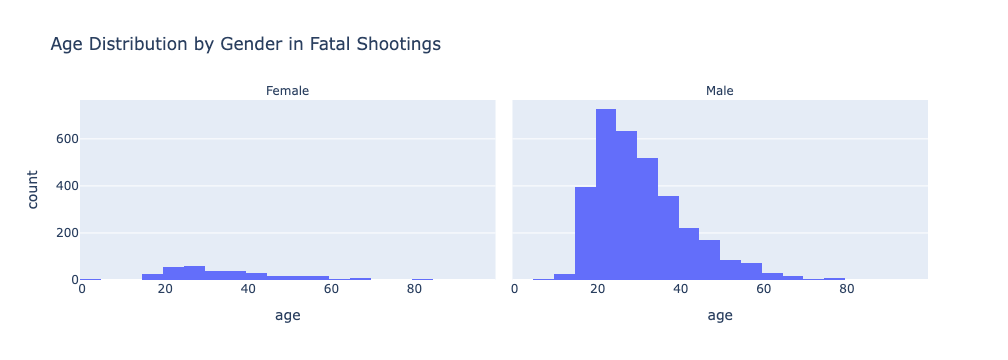

,sex,count,Percentage
0,F,321,8.9
1,M,3304,91.1


In [8]:
shoot_df2 = shoot_df2.dropna(subset=['sex'])
shoot_df2 = shoot_df2[shoot_df2['fatal'] == True]
age_gender = px.histogram(
    shoot_df2,
    x='age',
    facet_col='sex',
    nbins=30,
    title='Age Distribution by Gender in Fatal Shootings'
)

age_gender.for_each_annotation(lambda a: a.update(
    text='Female' if 'F' in a.text else 'Male'
))

age_gender.show()

sex_table = (
    shoot_df2
    .dropna(subset=['sex'])
    .groupby('sex')
    .size()
    .reset_index(name='count')
)
sex_table['Percentage'] = ((sex_table['count'] / sex_table['count'].sum())*100).round(1)
sex_table

As indicated by the graphs and table above, the number of male victims in fatal shootings is significantly greater than the number of female victims. Men account for 91.1% of fatal shootings in Philadelphia, closely aligning with the same proportion reported by GW. More broadly, gun violence in the city disproportionately affects young men, particularly those in their early to mid-twenties, with approximately 20% of all shooting-related deaths occurring among men aged 20–24. This concentration highlights a clear demographic pattern in who is most at risk.

Women, by contrast, account for only 8.9% of shooting-related deaths, and their age distribution differs somewhat from that of men. While male fatalities are heavily concentrated among younger age groups, female victims show a relatively higher representation in their 30s and 40s. This suggests that, although women are far less frequently victims of fatal shootings, the circumstances and patterns of victimization may differ in meaningful ways across gender and age groups.

## Change Over Time

To better understand how gun violence has evolved in Philadelphia, it is important to examine trends in fatal shootings over time. While demographic patterns reveal who is most affected, a temporal analysis highlights whether the scale of violence is increasing, decreasing, or remaining stable, providing important context for understanding the trajectory of gun violence in the city.

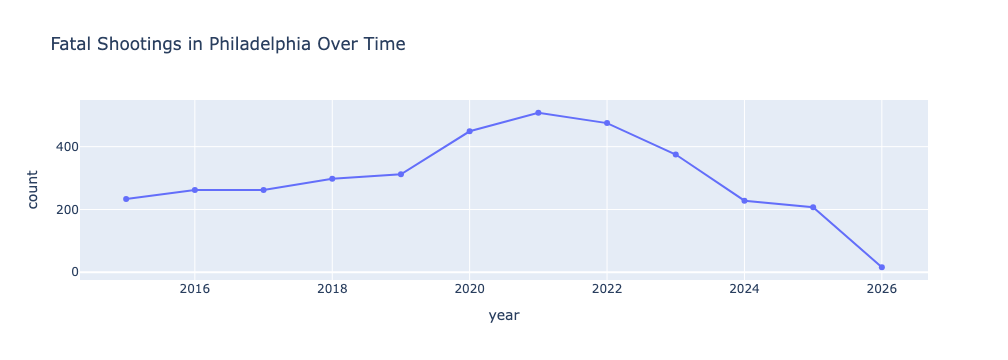

In [9]:
year_counts = (
    shoot_df2
    .groupby('year')
    .size()
    .reset_index(name='count')
)

year_graph = px.line(
    year_counts,
    x='year',
    y='count',
    markers=True,
    title='Fatal Shootings in Philadelphia Over Time'
)

year_graph.show()

The trend in fatal shootings in Philadelphia reveals a clear rise followed by a notable decline over the past decade. From 2015 through 2019, the number of fatal shootings increased gradually, suggesting a steady escalation in gun violence. This upward trend accelerated sharply beginning in 2020, with fatalities peaking around 2021 at just over 500 deaths: the highest point in the dataset.

Following this peak, fatal shootings began to decline each year, with a particularly steep drop between 2022 and 2024. By 2025, the number of fatal shootings had fallen to levels comparable to those seen before the pandemic-era surge. The sharp decline observed in 2026 likely reflects incomplete data for that year rather than a true drop to near-zero fatalities.

Overall, this pattern suggests that while Philadelphia experienced a significant surge in fatal gun violence during the early 2020s, recent years have seen meaningful reductions. However, even with this decline, fatal shooting levels remain elevated compared to earlier years in the dataset, indicating that gun violence continues to be a persistent issue.

## Conclusion

Gun violence in Philadelphia follows patterns. Who gets shot, where they’re hit, and when the violence occurs all shape whether a victim lives or dies. Young men bear the greatest burden, and wounds to vital areas like the head and torso dramatically increase the likelihood of death. While recent declines in fatalities offer some hope, the data makes one thing clear: survival is deeply tied to the circumstances of the shooting. 